<a href="https://colab.research.google.com/github/kwill37188-dotcom/May26_codeBMB/blob/main/007_AI_Gemini_Coding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<img align="right" src="https://github.com/codeBMB/May26_codeBMB/raw/main/images/PyBMB_logo.png" width="150" height="150" />

# Project: CodeBMB: Computational Literacy for Biochemistry and Molecular Biology Education
## Notebook 007: Using AI to accelerate your Python coding

**Purpose:**
This notebook adapts notebook 004 and has you alter the notebook in ways that could be aided by the use of Gemini. This similar to what you might do to produce a notebook for students or teach students to do when coding to help them work through issues.

**Input Data:**
* **Description:** Bradford assay standard curve — BSA standards
  with three replicates at six concentrations (0.00–0.50 mg/mL)
  measured at 595 nm.
* **Source:** `bsa_std_curve.csv` — CodeBMB April 2026 workshop dataset
* **Retrieved On:** 2025-04-26
* **Access:** Downloaded automatically from CodeBMB GitHub repository

**Libraries:**
* `pandas` — loading and organizing data in DataFrames
* `numpy` — numerical operations and generating best-fit line points
* `matplotlib` — creating and customizing plots
* `scipy.stats` — performing linear regression with `linregress`

**Status with Date:** May 2026, work in progress

**License**

<img src="https://github.com/codeBMB/May26_codeBMB/raw/main/images/by-nc-sa.png" width="100"/>

CC BY-NC-SA — reusers may distribute, remix, adapt, and build upon
the material for noncommercial purposes only, with attribution,
under identical terms.

---
**Authorship:** Chris Berndsen based on a notebook by Zinedine Sehili, Paul Craig, Wally Novak

**Acknowledgements:** This workshop is supported by NSF IUSE 2518733.

**Contact Info:** codingforBMB@gmail.com

## Using Gemini to Write & Adapt Python Code

One of the most frustrating issues while learning to code is getting stuck and not knowing the question to ask. An experienced coder might use a term like tuple to describe the data while you might call it a list or you might not even know the customization options for some of the libraries such as when making a plot with `matplotlib` or `seaborn`.

Google Colab has the large language model (LLM) Gemini incorporated into its architecture. This "AI-assisted" coding can help identify and fix errors, develop new code, and provided limited explanations for coding. This can be especially useful with working code that you want to customize but may not know exactly how.

---

### How to access Gemini

1. The star button at the bottom center of the browser window while in Colab
2. The pen with sparkle in the upper right side menu in a coding block
3. In a separate browser tab at https://gemini.google.com/



In [1]:
#@title Setup - Run this First, it recreates the 004 data
#@markdown This recreates the standard curve from Notebook 004 so you have
#@markdown the same `slope`, `intercept`, `r_squared`, `clean_data_df`, and plot
#@markdown you've already worked with.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Assay parameters (same as 004)

conc_units        = 'mg/mL'
concentration_col = 'Concentration_mg_per_mL'
replicate_cols    = ['Rep1', 'Rep2', 'Rep3']

# Standard curve data (same as 004)
std_curve_data = {
    concentration_col: [0.00, 0.10, 0.20, 0.30, 0.40, 0.50],
    'Rep1': [-0.004, 0.118, 0.238, 0.356, 0.478, 0.596],
    'Rep2': [ 0.001, 0.121, 0.242, 0.361, 0.482, 0.601],
    'Rep3': [ 0.003, 0.124, 0.245, 0.364, 0.485, 0.604],
}
df = pd.DataFrame(std_curve_data)
clean_data_df = df.dropna().copy()

# Calculate mean, std, regression
clean_data_df['average'] = clean_data_df[replicate_cols].mean(axis=1)
clean_data_df['std_dev'] = clean_data_df[replicate_cols].std(axis=1)

concentration      = clean_data_df[concentration_col]
average_absorbance = clean_data_df['average']

slope, intercept, r_value, p_value, std_err = stats.linregress(
    concentration, average_absorbance
)
r_squared = r_value**2

clean_data_df.head()
print(f'   slope={slope:.4f}  intercept={intercept:.4f}  R²={r_squared:.4f}')

   slope=1.2007  intercept=0.0007  R²=1.0000


---

Gemini is most useful when you already understand what you want
to do but need help with the syntax. It is least useful when you
ask it to write code from scratch. You will get an answer but not understand how to derive the code for other purposes or how it breaks.

| Gemini is **useful** for... | Gemini **cannot** know... |
|---|---|
| Exact parameter names for `plt.scatter`, `ax.text`, etc. | Whether your R² is good for Bradford assay |
| How to add a column to a DataFrame | Whether your dilution factor is correct |
| Fixing a syntax error | Whether your sample concentrations make biological sense |
| Remembering `axis=1` vs `axis=0` | What your experiment is actually measuring |

**Before asking Gemini anything, finish this sentence:**
> *"I want my code to do ___, but I don't know the Python syntax for ___."*

If you can't finish it, you should consider taking more time to get the vocabulary to describe what you want precisely.

---

## What Makes a Good Coding Prompt?

A good prompt has **3 parts**:

```
[CONTEXT]  What you already have — variable names, libraries in use
[GOAL]     Exactly what you want to change or add
[FORMAT]   Ask for a short snippet or a full tutorial or no explanation at all
```

**Specific variable names + specific goal + specific format = useful answer.**


### Weak prompt:
```
How do I change my matplotlib plot?
```

### Strong prompt:
```
I have a matplotlib plot made with plt.errorbar() and plt.plot().
The best-fit line is currently color='red'.
I want to change it to a dark green dashed line.
Show me just the updated plt.plot() line with both changes — no explanation.
```



---

### Section 1 — Run the baseline plot

This is the plot from Notebook 004.
Read every line before you change anything to remember what this plot shows.

Add a comment on any line you're not sure about.

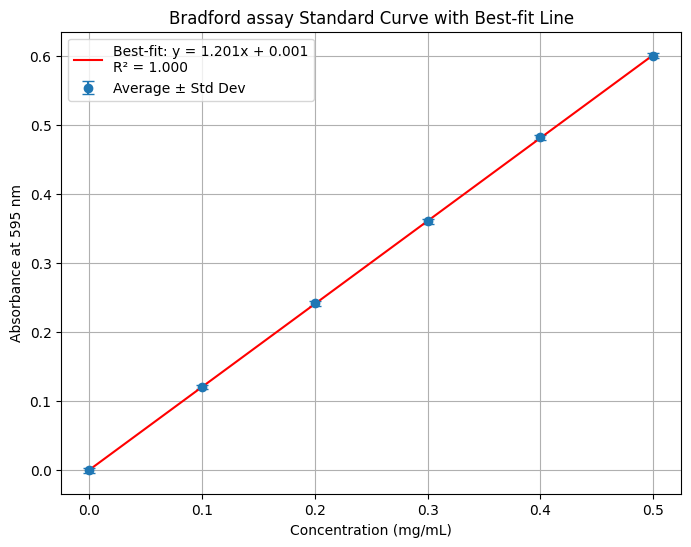

In [4]:
wavelength = 595 # nm, based on notebook description
assay_name = 'Bradford assay' # based on notebook description

# BASELINE PLOT from 004
# Read this carefully — every parameter is labeled

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='o',              # <-- 'o' means circular markers
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line
plt.plot(
    line_x, line_y,
    color='red',          # <-- line color
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.show()

---
### Section 2 — Your Three Tasks (+ Two for Fun)

Open your preferred **Gemini** access point. Design a prompt to separately alter the plot below as indicated in each task. There is a separate plotting window for each one.

---

1. Change the marker style on `plt.errorbar`

2. Change the best-fit line to dark green and dashed

3. Save the figure as a high-resolution PNG using plt.savefig()

4. CHALLENGE #1: Add a second y-axis showing concentration on the right side while absorbance stays on the left

5. CHALLENGE #2: Plot the residuals and then add it to the existing figure as a subplot


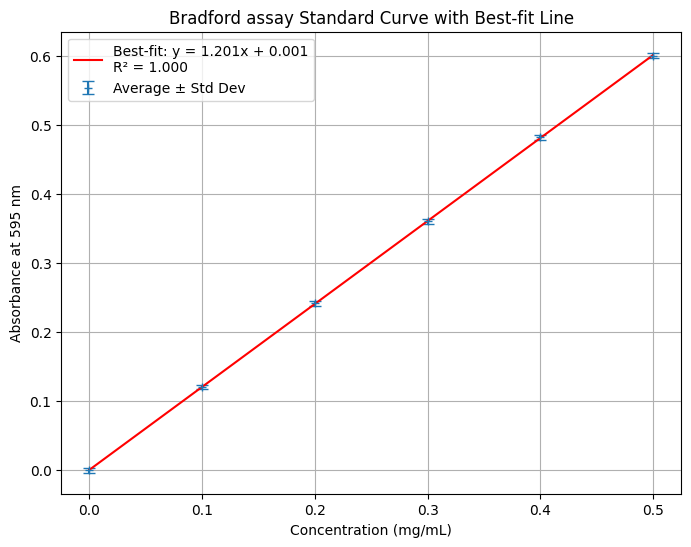

In [5]:
# Task 1 plot -- change the marker style on plt.errorbar

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='+',
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line
plt.plot(
    line_x, line_y,
    color='red',          # <-- line color
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.show()

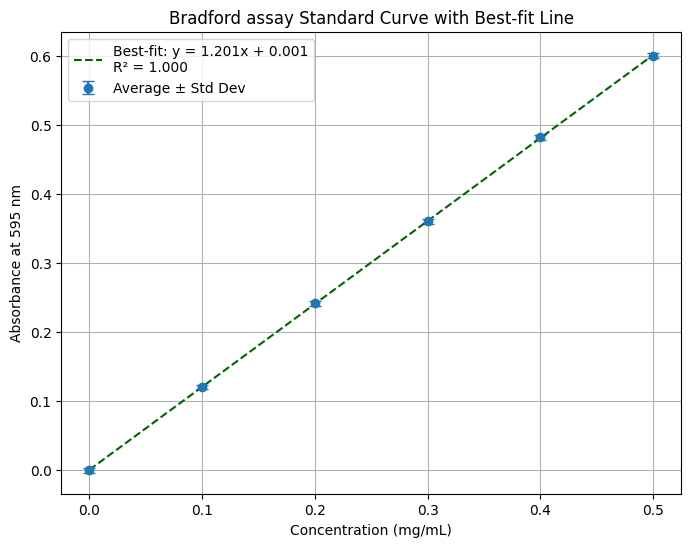

In [6]:
# Task 2 plot -- Change the best-fit line to dark green and dashed

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='o',              # <-- 'o' means circular markers
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line
plt.plot(
    line_x, line_y,
    color='darkgreen',    # <-- line color changed to dark green
    linestyle='--',       # <-- line style changed to dashed
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.show()

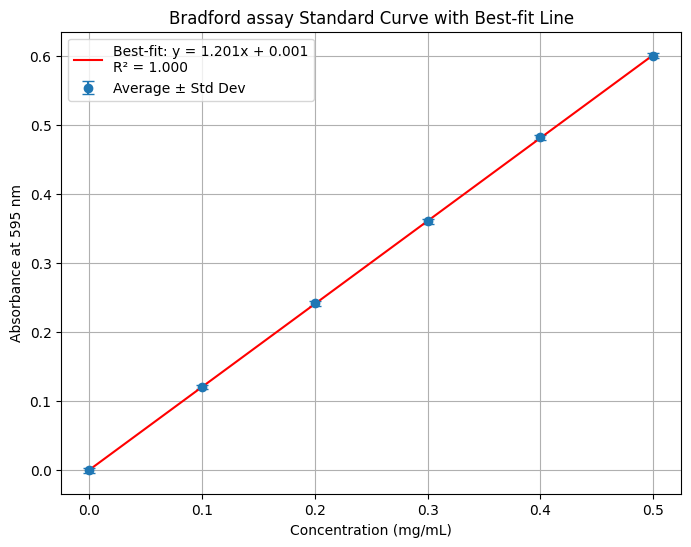

In [8]:
# Task 3 plot -- Save the figure as a high-resolution PNG using plt.savefig()

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='o',              # <-- 'o' means circular markers
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line
plt.plot(
    line_x, line_y,
    color='red',          # <-- line color
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.savefig('standard_curve.png', dpi=300) # Save figure as high-resolution PNG
plt.show()

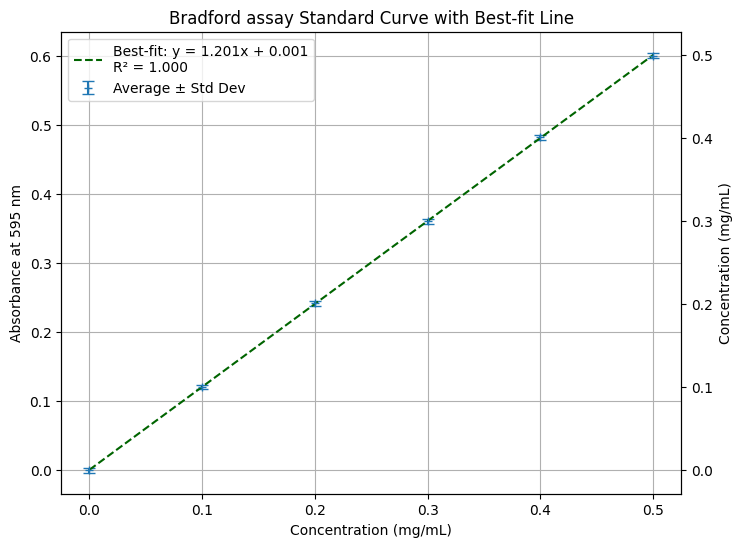

In [10]:
# Task 4 plot -- Add a second y-axis showing concentration on the right side while absorbance stays on the left

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

fig, ax1 = plt.subplots(figsize=(8, 6)) # Create figure and first axis

# Error bar data points on ax1
ax1.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='+',              # <-- Changed from 'o' to '+' (from Task 1)
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line on ax1
ax1.plot(
    line_x, line_y,
    color='darkgreen',    # <-- Changed from 'red' to 'darkgreen' (from Task 2)
    linestyle='--',       # <-- Added dashed linestyle (from Task 2)
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

ax1.set_xlabel(f'Concentration ({conc_units})')
ax1.set_ylabel(f'Absorbance at {wavelength} nm')
ax1.set_title(f'{assay_name} Standard Curve with Best-fit Line')
ax1.grid(True)
ax1.legend(loc='upper left')

# Create a second y-axis sharing the same x-axis
ax2 = ax1.twinx()

# Explicitly set the y-limits for the primary absorbance axis (ax1)
# to ensure the concentration axis starts at a sensible value (e.g., 0 or near 0)
min_abs_display = 0.0 # Start absorbance axis at 0
max_abs_display = average_absorbance.max() * 1.1 # Extend slightly above max average absorbance
ax1.set_ylim(min_abs_display, max_abs_display)

# Calculate the corresponding concentration for the absorbance limits of ax1
# conc = (absorbance - intercept) / slope
min_abs_current, max_abs_current = ax1.get_ylim()
min_conc = (min_abs_current - intercept) / slope
max_conc = (max_abs_current - intercept) / slope

ax2.set_ylim(min_conc, max_conc)
ax2.set_ylabel(f'Concentration ({conc_units})')

plt.show()

In [ ]:
# Task 5 plot -- Plot the residuals and then add it to the existing figure as a subplot

line_x = np.linspace(concentration.min(), concentration.max(), 100)
line_y = slope * line_x + intercept

plt.figure(figsize=(8, 6))

# Error bar data points
plt.errorbar(
    concentration,
    average_absorbance,
    yerr=clean_data_df['std_dev'],
    fmt='o',              # <-- 'o' means circular markers
    capsize=4,
    label='Average ± Std Dev'
)

# Best-fit line
plt.plot(
    line_x, line_y,
    color='red',          # <-- line color
    label=f'Best-fit: y = {slope:.3f}x + {intercept:.3f}\nR² = {r_squared:.3f}'
)

plt.xlabel(f'Concentration ({conc_units})')
plt.ylabel(f'Absorbance at {wavelength} nm')
plt.title(f'{assay_name} Standard Curve with Best-fit Line')
plt.grid(True)
plt.legend()
plt.show()

---
### Section 3 — When Gemini Misses and Quick Fixes

Below are some common issues in Gemini responses and suggestions for a follow up prompt to adjust the output to align more with the expected answer.

| Problem | Add to your prompt |
|---------|--------------------|
| Used wrong variable name | *"My variable is called `clean_data_df`, not `df`"* |
| Gave a full tutorial | *"Give me just the code, no explanation"* |
| Used a library you don't have | *"Use only numpy, pandas, matplotlib, scipy — no seaborn"* |
| Gave you an error | Paste the full error: *"I got this error: [paste]. How do I fix it?"* |
| Used `ax.plot()` but you used `plt.plot()` | *"I am using plt.plot(), not the ax object style"* |
| Answer was for a different function | Paste your actual line: *"My current line is: `plt.errorbar(..., fmt='o', ...)`"* |

---

## Wrap-Up

> **The most important thing you bring to this collaboration is understanding your experiment.**  
> Gemini speeds up your syntax. It doesn't replace your scientific judgment.


## Gemini Inside Colab vs. AI Tools in a Separate Tab

You have two ways to get AI coding help. They work differently and are useful for different things.

---

### Option 1 — Gemini sidebar (inside Colab)
Gemini can read your notebook directly — your variable names, your code, your error messages.
You can highlight a cell and ask it to explain or fix without copy-pasting anything.

**The catch:** because it reads your notebook automatically, it's easy to get an answer
without fully understanding what you asked. That's fine once you're experienced.
For learning, it can short-circuit the thinking.

---

### Option 2 — AI in a separate tab (Claude, ChatGPT, Gemini.google.com)
You copy your code in, write a prompt, and paste the answer back.

Writing a prompt forces you to:
- identify exactly what you have (your variable names, your libraries)
- state exactly what you want
- understand the answer before you paste it in

**This is the workflow we're practicing today.**

---

### The honest comparison

| | Gemini in Colab | AI in separate tab |
|---|---|---|
| Sees your notebook | Automatically | Only what you paste in |
| Good for beginners | Can skip the thinking | Forces good habits |
| Good for experienced users | Fast | Slower |
| Choice of AI tool | Gemini only | Claude, ChatGPT, Gemini |